<a href="https://colab.research.google.com/github/999ssg/amazon-hybrid-recommendation-system/blob/main/Amazon_Product_Recommendation_System_%E2%80%94Industry_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Questions

# **Section A: Data Understanding & Cleaning:**

1. **Understand the dataset like a data scientist in a product analytics team.**
    
  **Summarize the dataset:**
    
  a. **Number of unique users, products, and reviews**

  b. **Top 5 categories by number of products**

  c. **Price range and discount insights**

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('amazon.csv')

# Clean price and discount fields
df['discounted_price'] = df['discounted_price'].replace('[₹,]', '', regex=True).astype(float)
df['actual_price'] = df['actual_price'].replace('[₹,]', '', regex=True).astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '').astype(float)

# Extract top-level category
df['top_category'] = df['category'].str.split('|').str[0]

# Expand comma-separated user_ids
user_data = df[['product_id', 'user_id']].copy()
user_data['user_id'] = user_data['user_id'].str.split(',')
user_data = user_data.explode('user_id')

# Summary calculations
n_unique_users = user_data['user_id'].nunique()
n_unique_products = df['product_id'].nunique()
n_reviews = user_data.shape[0]

top_categories = df['top_category'].value_counts().head(5)

min_price = df['discounted_price'].min()
max_price = df['discounted_price'].max()
avg_price = df['discounted_price'].mean()

min_discount = df['discount_percentage'].min()
max_discount = df['discount_percentage'].max()
avg_discount = df['discount_percentage'].mean()

# Output summary
print("Dataset Summary:")
print(f"Unique Users: {n_unique_users}")
print(f"Unique Products: {n_unique_products}")
print(f"Total Reviews: {n_reviews}\n")

print("Top 5 Categories by Number of Products:")
print(top_categories.to_string(), "\n")

print("Price Insights:")
print(f"Price Range: ₹{min_price:.2f} – ₹{max_price:.2f}")
print(f"Average Price: ₹{avg_price:.2f}\n")

print("Discount Insights:")
print(f"Discount Range: {min_discount:.0f}% – {max_discount:.0f}%")
print(f"Average Discount: {avg_discount:.2f}%")


Dataset Summary:
Unique Users: 9050
Unique Products: 1351
Total Reviews: 11503

Top 5 Categories by Number of Products:
top_category
Electronics              526
Computers&Accessories    453
Home&Kitchen             448
OfficeProducts            31
MusicalInstruments         2 

Price Insights:
Price Range: ₹39.00 – ₹77990.00
Average Price: ₹3125.31

Discount Insights:
Discount Range: 0% – 94%
Average Discount: 47.69%




---



2. **Clean and preprocess the data:**

  a. **Convert prices to numeric**

  b. **Parse categories into hierarchy levels**

  c. **Normalize rating scores and count outliers or Create derived features like price_difference, value_for_money_score, weighted ratings.**

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('amazon.csv')

# ---------------------------------------
#  Step 1: Convert prices and discounts to numeric
df['discounted_price'] = df['discounted_price'].replace('[₹,]', '', regex=True).astype(float)
df['actual_price'] = df['actual_price'].replace('[₹,]', '', regex=True).astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '').astype(float)

# ---------------------------------------
#  Step 2: Safely parse category hierarchy levels
category_split = df['category'].str.split('|', expand=True)
df['level_1_category'] = category_split[0]
df['level_2_category'] = category_split[1] if category_split.shape[1] > 1 else np.nan
df['level_3_category'] = category_split[2] if category_split.shape[1] > 2 else np.nan

# Fill missing levels with "Unknown"
df['level_2_category'] = df['level_2_category'].fillna("Unknown")
df['level_3_category'] = df['level_3_category'].fillna("Unknown")

# ---------------------------------------
#  Step 3: Normalize rating scores
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')  # ensure rating is numeric
rating_min = df['rating'].min()
rating_max = df['rating'].max()
df['normalized_rating'] = (df['rating'] - rating_min) / (rating_max - rating_min)

# ---------------------------------------
#  Step 4: Count rating outliers
low_rating_outliers = df[df['rating'] <= 1].shape[0]
high_rating_outliers = df[df['rating'] >= 5].shape[0]
print(f"Low Rating Outliers (<=1): {low_rating_outliers}")
print(f"High Rating Outliers (>=5): {high_rating_outliers}")

# ---------------------------------------
#  Step 5: Create derived features

# a. Price difference
df['price_difference'] = df['actual_price'] - df['discounted_price']

# b. Value for money score = normalized_rating / (discounted_price + 1)
df['value_for_money_score'] = df['normalized_rating'] / (df['discounted_price'] + 1)

# c. Convert rating count to numeric
df['rating_count'] = df['rating_count'].replace(',', '', regex=True).astype(float)

# d. Weighted rating = rating × log(1 + rating_count)
df['weighted_rating'] = df['rating'] * np.log1p(df['rating_count'])

# ---------------------------------------
# 🔍 Preview derived features
print("\n Sample with Derived Features:")
print(df[['product_name', 'discounted_price', 'actual_price', 'price_difference',
          'rating', 'normalized_rating', 'value_for_money_score', 'weighted_rating']].head())


Low Rating Outliers (<=1): 0
High Rating Outliers (>=5): 3

 Sample with Derived Features:
                                        product_name  discounted_price  \
0  Wayona Nylon Braided USB to Lightning Fast Cha...             399.0   
1  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...             199.0   
2  Sounce Fast Phone Charging Cable & Data Sync U...             199.0   
3  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...             329.0   
4  Portronics Konnect L 1.2M Fast Charging 3A 8 P...             154.0   

   actual_price  price_difference  rating  normalized_rating  \
0        1099.0             700.0     4.2           0.733333   
1         349.0             150.0     4.0           0.666667   
2        1899.0            1700.0     3.9           0.633333   
3         699.0             370.0     4.2           0.733333   
4         399.0             245.0     4.2           0.733333   

   value_for_money_score  weighted_rating  
0               0.001833        42.



---



3. **Handle missing values or anomalies**

  **Remove duplicates, invalid records**
  
  **Handle missing ratings or reviews with appropriate strategy**

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("amazon.csv")

# ---------------------------------------------
#  Step 1: Remove duplicates
df.drop_duplicates(inplace=True)
print(f"Duplicates removed. Remaining rows: {df.shape[0]}")

# ---------------------------------------------
#  Step 2: Convert key columns to numeric types
df['discounted_price'] = df['discounted_price'].replace('[₹,]', '', regex=True).astype(float)
df['actual_price'] = df['actual_price'].replace('[₹,]', '', regex=True).astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '', regex=True).astype(float)

# ---------------------------------------------
#  Step 3: Clean rating and rating_count
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = df['rating_count'].replace(',', '', regex=True).astype(float)

# ---------------------------------------------
#  Step 4: Handle missing or invalid records

# Strategy: Drop records where product_name or prices are missing
df.dropna(subset=['product_name', 'discounted_price', 'actual_price'], inplace=True)

# Strategy for missing rating:
# ➤ If rating is missing but rating_count > 0 → fill with average rating
# ➤ If rating is missing and no rating_count → fill with neutral rating (e.g., 3.0)
average_rating = df['rating'].mean()
df['rating'] = df.apply(
    lambda row: average_rating if pd.isna(row['rating']) and row['rating_count'] > 0
    else (3.0 if pd.isna(row['rating']) else row['rating']),
    axis=1
)

# Strategy for missing rating_count: fill with 0
df['rating_count'] = df['rating_count'].fillna(0)

# ---------------------------------------------
#  Step 5: Summary of cleaning
print("\n📋 Missing Values Summary AFTER Cleaning:")
print(df.isnull().sum())

# Preview cleaned data
print("\n Cleaned data preview:")
print(df[['product_name', 'rating', 'rating_count', 'discounted_price', 'actual_price']].head())


Duplicates removed. Remaining rows: 1465

📋 Missing Values Summary AFTER Cleaning:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

 Cleaned data preview:
                                        product_name  rating  rating_count  \
0  Wayona Nylon Braided USB to Lightning Fast Cha...     4.2       24269.0   
1  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...     4.0       43994.0   
2  Sounce Fast Phone Charging Cable & Data Sync U...     3.9        7928.0   
3  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...     4.2       94363.0   
4  Portronics Konnect L 1.2M Fast Charging 3A 8 P...     4.2       16905.0   

   discount



---



# **Section B: Exploratory Data Analysis: Think like a product analyst trying to identify buying patterns**

**Visualize:**

  **a. Most reviewed products Visualize top 10 categories by number of products.**

  **b. Average rating per category**

  **c. Discounts vs actual price correlation**

**User Engagement Insights (5 marks)**
    
  **a. Which products have high ratings but low review counts?**

  **b. Are highly rated products also heavily reviewed?**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')


/tmp/ipython-input-6-3618671009.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_reviewed, y='product_name', x='rating_count', palette='viridis')


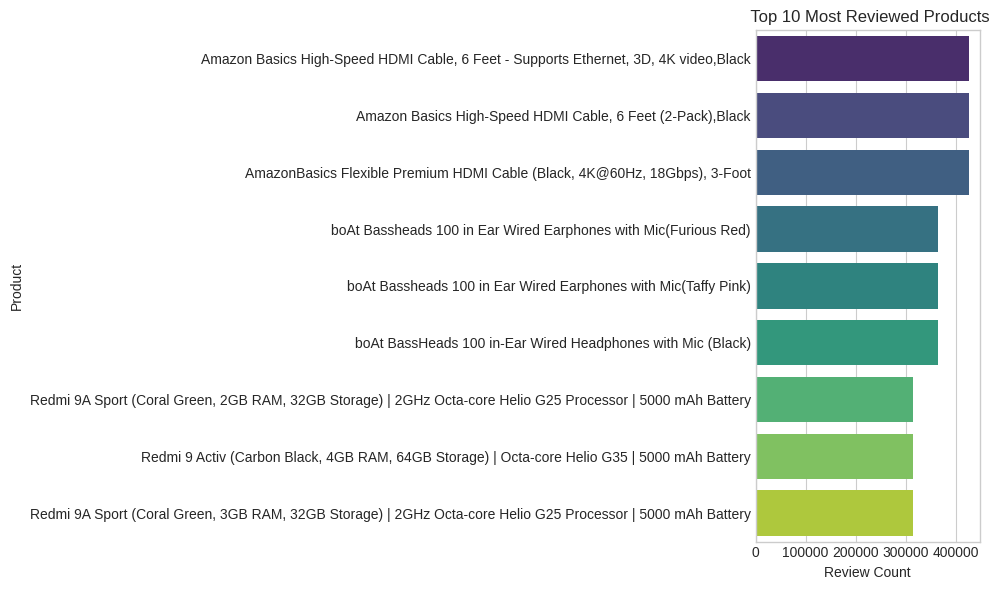

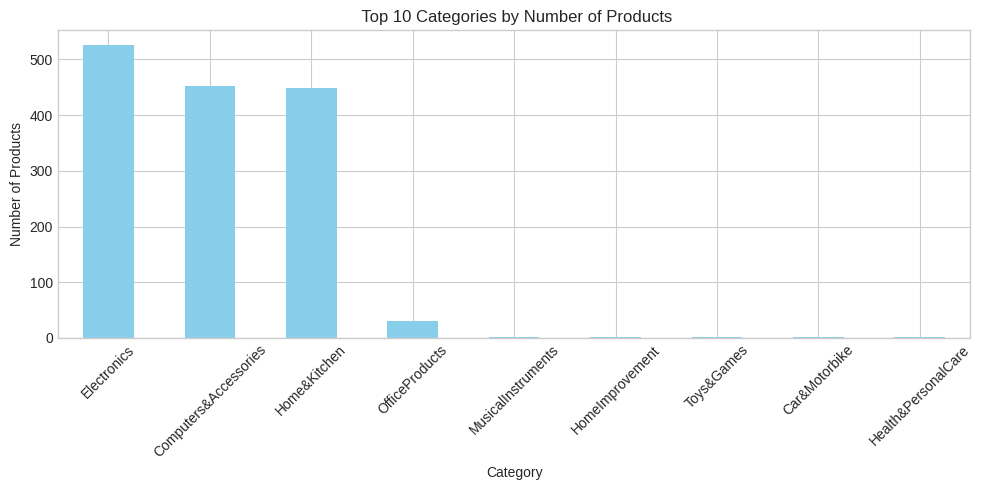

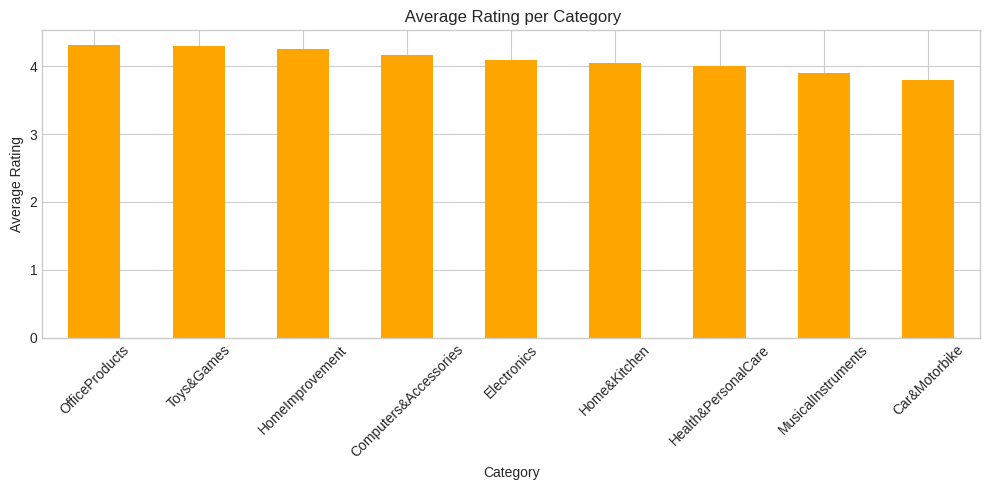

/tmp/ipython-input-6-3618671009.py:53: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


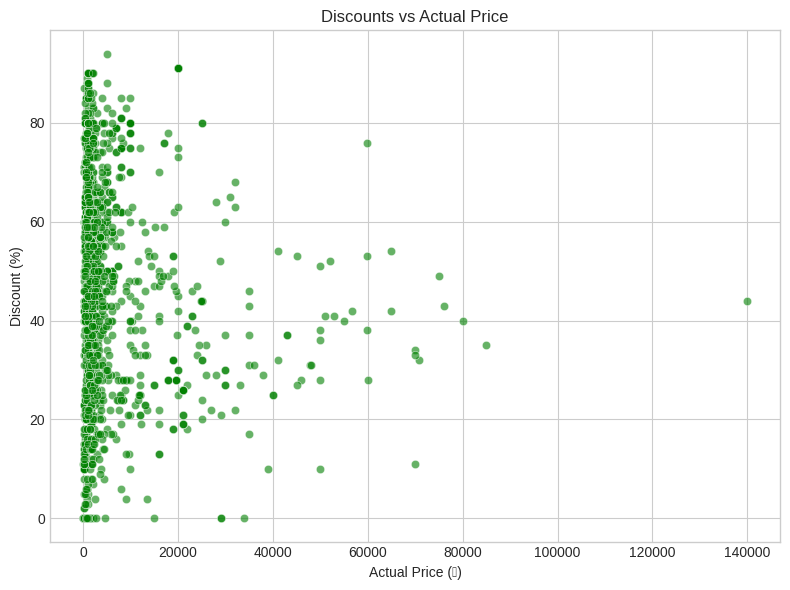


 Products with High Rating but Low Review Count:
                                           product_name  rating  rating_count
174   Syncwire LTG to USB Cable for Fast Charging Co...     5.0           5.0
1293  Melbon VM-905 2000-Watt Room Heater (ISI Certi...     4.6           9.0
299   WANBO X1 Pro (Upgraded) | Native 1080P Full HD...     4.5           7.0


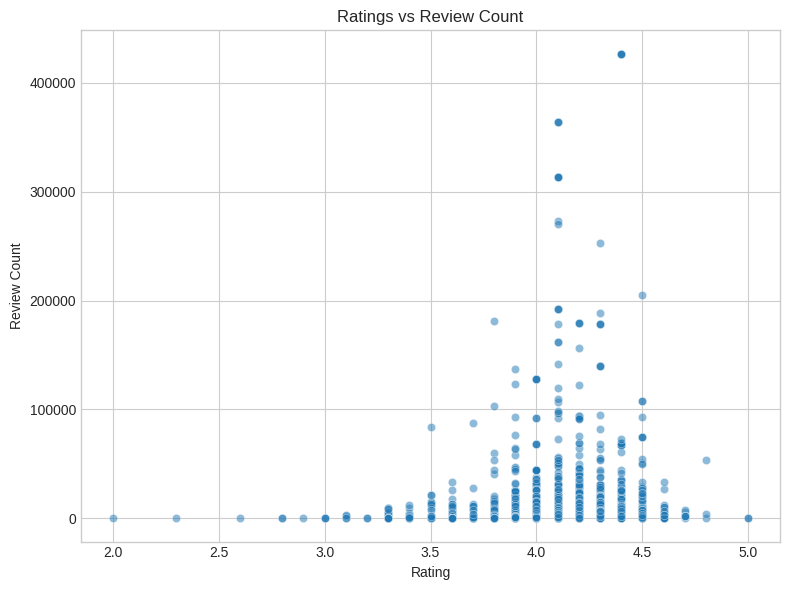


 Correlation between Rating and Review Count: 0.102


In [ ]:
# Load and preprocess your cleaned dataset
df = pd.read_csv('amazon.csv')

# --- Clean price and rating-related fields again if needed ---
df['discounted_price'] = df['discounted_price'].replace('[₹,]', '', regex=True).astype(float)
df['actual_price'] = df['actual_price'].replace('[₹,]', '', regex=True).astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '', regex=True).astype(float)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = df['rating_count'].replace(',', '', regex=True).astype(float)
df['category_level_1'] = df['category'].str.split('|').str[0]

# ------------------------------
#  1. Most reviewed products
top_reviewed = df.sort_values(by='rating_count', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_reviewed, y='product_name', x='rating_count', palette='viridis')
plt.title(' Top 10 Most Reviewed Products')
plt.xlabel('Review Count')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

# ------------------------------
#  2. Top 10 categories by number of products
plt.figure(figsize=(10, 5))
df['category_level_1'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title(' Top 10 Categories by Number of Products')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------
#  3. Average rating per category
category_rating = df.groupby('category_level_1')['rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
category_rating.plot(kind='bar', color='orange')
plt.title(' Average Rating per Category')
plt.ylabel('Average Rating')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------
#  4. Discounts vs Actual Price Correlation
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='actual_price', y='discount_percentage', alpha=0.6, color='green')
plt.title('Discounts vs Actual Price')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Discount (%)')
plt.tight_layout()
plt.show()

# ------------------------------
#  5. User Engagement Insights

# (a) Products with high rating but low review count
high_rating_low_reviews = df[(df['rating'] >= 4.5) & (df['rating_count'] < 10)].sort_values(by='rating', ascending=False)
print("\n Products with High Rating but Low Review Count:")
print(high_rating_low_reviews[['product_name', 'rating', 'rating_count']].head(10))

# (b) Correlation between ratings and reviews
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='rating', y='rating_count', alpha=0.5)
plt.title('Ratings vs Review Count')
plt.xlabel('Rating')
plt.ylabel('Review Count')
plt.tight_layout()
plt.show()

# Pearson correlation coefficient
correlation = df[['rating', 'rating_count']].corr().iloc[0, 1]
print(f"\n Correlation between Rating and Review Count: {correlation:.3f}")




---



**Create 3 actionable insights for Amazon’s product strategy based on EDA.**

1. **High-Rated, Under-Reviewed Products**

**Insight: Several products have ratings above 4.5 but very few reviews.**

**Action:**

  **These products are potentially excellent but lacks in visibility.**

  **Introduce discounts or rewards to encourage verified buyers to leave reviews.**

  **Promote these products through Hidden Gems sections on the homepage**

2. **Discounts for Mid-Priced Items**

**Insight: There's a positive correlation between product price and discount % — but beyond a threshold, higher discounts don’t significantly boost rating or review count.**

**Action:**

**Focus discount strategies on mid-range products (₹2,000–₹5,000), where customers are more likely to be price-sensitive.**

3.  **Prioritize High Engagement & Positive Ratings**

**Insight: Categories like Electronics, Computers & Accessories, and Home & Kitchen dominate both: Product volume & User engagement (ratings & reviews).**

**Action:**

**Double down on personalization and inventory depth in these high-performing categories.**

**Launch category-specific recommendation systems, bundles, and curated lists.**

**Introduce "Most Reviewed" or "Top Rated" filters to help customers discover popular items quickly**

In [ ]:
import pandas as pd
import numpy as np

# Load and clean data
df = pd.read_csv("amazon.csv")
df['discounted_price'] = df['discounted_price'].replace('[₹,]', '', regex=True).astype(float)
df['actual_price'] = df['actual_price'].replace('[₹,]', '', regex=True).astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '', regex=True).astype(float)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = df['rating_count'].replace(',', '', regex=True).astype(float)
df['category_level_1'] = df['category'].str.split('|').str[0]

# ---------------------------------------------------------
# Insight 1: High-rated but under-reviewed products
quietly_loved = df[(df['rating'] >= 4.5) & (df['rating_count'] < 10)]
print("Products with High Rating (>=4.5) but Low Review Count (<10):")
print(quietly_loved[['product_name', 'rating', 'rating_count']].sort_values(by='rating', ascending=False).head(10))

# ---------------------------------------------------------
# Insight 2: Discount vs. Price Analysis (Correlation)
discount_price_corr = df[['actual_price', 'discount_percentage']].corr().iloc[0, 1]
print(f"\n Correlation between Actual Price and Discount Percentage: {discount_price_corr:.2f}")

# Suggest optimal discount band for mid-priced products
mid_priced = df[(df['actual_price'] >= 2000) & (df['actual_price'] <= 5000)]
avg_discount_mid = mid_priced['discount_percentage'].mean()
print(f"Average Discount for Mid-Priced Products (₹2K–₹5K): {avg_discount_mid:.2f}%")

# ---------------------------------------------------------
# Insight 3: Top categories by number of products & average rating
top_categories = df['category_level_1'].value_counts().head(5)
avg_rating_per_cat = df.groupby('category_level_1')['rating'].mean().sort_values(ascending=False)

print("\n Top 5 Categories by Number of Products:")
print(top_categories)

print("\n Average Rating per Top-Level Category:")
print(avg_rating_per_cat.head(10))


Products with High Rating (>=4.5) but Low Review Count (<10):
                                           product_name  rating  rating_count
174   Syncwire LTG to USB Cable for Fast Charging Co...     5.0           5.0
1293  Melbon VM-905 2000-Watt Room Heater (ISI Certi...     4.6           9.0
299   WANBO X1 Pro (Upgraded) | Native 1080P Full HD...     4.5           7.0

 Correlation between Actual Price and Discount Percentage: -0.12
Average Discount for Mid-Priced Products (₹2K–₹5K): 46.64%

 Top 5 Categories by Number of Products:
category_level_1
Electronics              526
Computers&Accessories    453
Home&Kitchen             448
OfficeProducts            31
MusicalInstruments         2
Name: count, dtype: int64

 Average Rating per Top-Level Category:
category_level_1
OfficeProducts           4.309677
Toys&Games               4.300000
HomeImprovement          4.250000
Computers&Accessories    4.154967
Electronics              4.081749
Home&Kitchen             4.040716
Health&Pe



---



# **Section C: Content-Based Filtering: Act like a content engineer personalizing user feeds based on product metadata.**



---



1. **Vectorize product text (about_product + product_name) using:**
  
  **TF-IDF or embeddings**
  
  **Build a product similarity matrix**

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Step 1: Load the dataset
df = pd.read_csv("amazon.csv")

# Step 2: Preprocess text columns
df['about_product'] = df['about_product'].fillna('')
df['product_name'] = df['product_name'].fillna('')
df['product_text'] = df['product_name'] + " " + df['about_product']

# Step 3: TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['product_text'])

# Step 4: Cosine Similarity Matrix
cosine_sim_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Step 5: Define robust similarity search function
def get_similar_products(product_name, top_n=5):
    # Match all rows with the given product_name
    matches = df[df['product_name'] == product_name]

    if matches.empty:
        return f" Product '{product_name}' not found in catalog."

    # Use the first matched product index
    idx = matches.index[0]

    # Get similarity scores for the product
    sim_scores = list(enumerate(cosine_sim_matrix[idx]))

    # Sort by similarity and exclude the product itself
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [x for x in sim_scores if x[0] != idx][:top_n]

    similar_indices = [i[0] for i in sim_scores]

    return df[['product_name', 'about_product']].iloc[similar_indices]

# ---------------------------------------
#  Example Usage
print(" Top 5 similar products to a given product:")
example_product = df['product_name'].iloc[0]
print(f"\n Query: {example_product}")
print(get_similar_products(example_product, top_n=5))


 Top 5 similar products to a given product:

 Query: Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Compatible for iPhone 13, 12,11, X, 8, 7, 6, 5, iPad Air, Pro, Mini (3 FT Pack of 1, Grey)
                                          product_name  \
369  Wayona Nylon Braided USB to Lightning Fast Cha...   
614  Wayona Nylon Braided USB to Lightning Fast Cha...   
220  Wayona Nylon Braided Usb Syncing And Charging ...   
42   Wayona Nylon Braided 3A Lightning to USB A Syn...   
89   Wayona Nylon Braided (2 Pack) Lightning Fast U...   

                                         about_product  
369  High Compatibility : Compatible With iPhone 12...  
614  High Compatibility : Compatible With iPhone 12...  
220  [High Compatibility] : iPhone X/XsMax/Xr ,iPho...  
42   [High Compatibility] : iPhone X/XsMax/Xr ,iPho...  
89   [High Compatibility] : iPhone X/XsMax/Xr ,iPho...  




---



2. **Recommend top 5 similar products to:**

  **A new product with no reviews**

  **A product with high user dropout (bad ratings)**

In [ ]:
def recommend_for_new_product(new_product_name, new_about_text, top_n=5):
    # Vectorize the new product
    new_text = new_product_name + " " + new_about_text
    new_vector = tfidf.transform([new_text])

    # Compute cosine similarity with all existing products
    similarities = cosine_similarity(new_vector, tfidf_matrix).flatten()

    # Get top N most similar products
    top_indices = similarities.argsort()[-top_n:][::-1]

    return df[['product_name', 'about_product']].iloc[top_indices]


In [ ]:
new_name = "Type-C Fast Charging Cable for Android and OnePlus"
new_about = "Nylon braided USB C cable, 3A fast charging, supports data sync, durable material, 1.5m length"

print("\n Top 5 Recommendations for New Product:")
print(recommend_for_new_product(new_name, new_about, top_n=5))



 Top 5 Recommendations for New Product:
                                          product_name  \
857  Wecool Nylon Braided Multifunction Fast Chargi...   
45   Wecool Nylon Braided Multifunction Fast Chargi...   
377  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
622  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
1    Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   

                                         about_product  
857  Special Features Of The Universal Cable: This ...  
45   Special Features Of The Universal Cable: This ...  
377  Compatible with all Type C enabled devices, be...  
622  Compatible with all Type C enabled devices, be...  
1    Compatible with all Type C enabled devices, be...  




---



3. **Add category, price, and discount to enhance content vectors**

**Evaluate recommendations:**
  **How diverse and relevant are the content-based results?**

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# -----------------------------------
# Step 1: Load & Preprocess
df = pd.read_csv("amazon.csv")

df['about_product'] = df['about_product'].fillna('')
df['product_name'] = df['product_name'].fillna('')
df['category'] = df['category'].fillna('')
df['product_text'] = df['product_name'] + " " + df['about_product'] + " " + df['category']

# Clean price and discount
df['actual_price'] = df['actual_price'].replace('[₹,]', '', regex=True).astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '', regex=True).astype(float)

# -----------------------------------
# Step 2: Normalize price & discount
scaler = MinMaxScaler()
df[['actual_price_scaled', 'discount_scaled']] = scaler.fit_transform(df[['actual_price', 'discount_percentage']])

# -----------------------------------
# Step 3: Vectorize text
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
text_features = tfidf.fit_transform(df['product_text'])

# -----------------------------------
# Step 4: Combine text + numeric features
from scipy.sparse import hstack

numeric_features = df[['actual_price_scaled', 'discount_scaled']].values
combined_features = hstack([text_features, numeric_features])

# -----------------------------------
# Step 5: Compute similarity matrix
cosine_sim_matrix = cosine_similarity(combined_features, combined_features)

# -----------------------------------
# Step 6: Recommend similar products
def get_similar_products_enhanced(product_name, top_n=5):
    matches = df[df['product_name'] == product_name]
    if matches.empty:
        return f" Product '{product_name}' not found."

    idx = matches.index[0]
    sim_scores = list(enumerate(cosine_sim_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [x for x in sim_scores if x[0] != idx][:top_n]
    similar_indices = [x[0] for x in sim_scores]

    return df[['product_name', 'category', 'actual_price', 'discount_percentage', 'about_product']].iloc[similar_indices]

# -----------------------------------
# Step 7: Try example
query_product = "Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Compatible for iPhone 13, 12,11, X, 8, 7, 6, 5, iPad Air, Pro, Mini (3 FT Pack of 1, Grey)"
print(f"\n Top 5 Enhanced Recommendations for:\n {query_product}\n")
print(get_similar_products_enhanced(query_product))



 Top 5 Enhanced Recommendations for:
 Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Compatible for iPhone 13, 12,11, X, 8, 7, 6, 5, iPad Air, Pro, Mini (3 FT Pack of 1, Grey)

                                          product_name  \
369  Wayona Nylon Braided USB to Lightning Fast Cha...   
614  Wayona Nylon Braided USB to Lightning Fast Cha...   
220  Wayona Nylon Braided Usb Syncing And Charging ...   
42   Wayona Nylon Braided 3A Lightning to USB A Syn...   
89   Wayona Nylon Braided (2 Pack) Lightning Fast U...   

                                              category  actual_price  \
369  Computers&Accessories|Accessories&Peripherals|...        1099.0   
614  Computers&Accessories|Accessories&Peripherals|...        1099.0   
220  Computers&Accessories|Accessories&Peripherals|...        1999.0   
42   Computers&Accessories|Accessories&Peripherals|...        1099.0   
89   Computers&Accessories|Accessories&Peripherals|...        1999.0   

     discount_p



---



# **Section D: Collaborative Filtering (User–Item) : Now you're a machine learning engineer building smart recommendations using user behavior.**



---



1. **Create a user-item matrix using user_id, product_id, and rating.**

In [ ]:
import pandas as pd

# Step 1: Load the dataset
df = pd.read_csv("amazon.csv")

# Step 2: Clean and convert rating column
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['user_id'] = df['user_id'].astype(str)
df['product_id'] = df['product_id'].astype(str)

# Drop rows where user_id, product_id, or rating is missing
df_cf = df.dropna(subset=['user_id', 'product_id', 'rating'])

# Step 3: Create User–Item Matrix
user_item_matrix = df_cf.pivot_table(
    index='user_id',
    columns='product_id',
    values='rating'
)

# Optional: Fill missing values (can be used in similarity calculation)
user_item_matrix_filled = user_item_matrix.fillna(0)

# View the matrix (head)
print(" User–Item Matrix (top 5 rows):")
print(user_item_matrix.head())


 User–Item Matrix (top 5 rows):
product_id                                          B002PD61Y4  B002SZEOLG  \
user_id                                                                      
AE22Y3KIS7SE6LI3HE2VS6WWPU4Q,AHWEYO2IJ5I5GDWZAH...         NaN         NaN   
AE23RS3W7GZO7LHYKJU6KSKVM4MQ,AEQUNEY6GQOTEGUMS6...         NaN         NaN   
AE242TR3GQ6TYC6W4SJ5UYYKBTYQ                               NaN         NaN   
AE27UOZENYSWCQVQRRUQIV2ZM7VA,AGMYSLV6NNOAYES25J...         NaN         NaN   
AE2JTMRKTUOIVIZWS2WDGTMNTU4Q,AF4QXCB32VC2DVE7O3...         NaN         NaN   

product_id                                          B003B00484  B003L62T7W  \
user_id                                                                      
AE22Y3KIS7SE6LI3HE2VS6WWPU4Q,AHWEYO2IJ5I5GDWZAH...         NaN         NaN   
AE23RS3W7GZO7LHYKJU6KSKVM4MQ,AEQUNEY6GQOTEGUMS6...         NaN         NaN   
AE242TR3GQ6TYC6W4SJ5UYYKBTYQ                               NaN         NaN   
AE27UOZENYSWCQVQRRUQIV2ZM7VA,AG



---



2. **Apply: User-User Collaborative Filtering (cosine similarity) OR Item-Item Collaborative Filtering (cosine or Pearson)**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Load raw dataset
df = pd.read_csv("amazon.csv", quotechar='"', escapechar='\\', skipinitialspace=True)

# Fix user_id column — explode it if user_id contains multiple IDs per row
df['user_id'] = df['user_id'].astype(str)

# Step 1: Split multiple user_ids per row (if they exist)
df['user_id'] = df['user_id'].str.split(',')

# Step 2: Explode to multiple rows (one user_id per row)
df = df.explode('user_id')

# Step 3: Clean and convert data types
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['user_id'] = df['user_id'].str.strip()
df['product_id'] = df['product_id'].astype(str)
df['product_name'] = df['product_name'].astype(str)

# Drop invalid rows
df_cf = df.dropna(subset=['user_id', 'product_id', 'rating'])

# Step 4: Create User-Item Matrix
user_item_matrix = df_cf.pivot_table(index='user_id', columns='product_id', values='rating')
user_item_matrix_filled = user_item_matrix.fillna(0)

# Step 5: Compute User Similarity Matrix
user_similarity = cosine_similarity(user_item_matrix_filled)
user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)

# Step 6: Predict ratings
def predict_rating(user_id, product_id):
    if user_id not in user_item_matrix.index or product_id not in user_item_matrix.columns:
        return np.nan
    product_ratings = user_item_matrix[product_id]
    users_who_rated = product_ratings[product_ratings.notna()].index
    similarities = user_similarity_df.loc[user_id, users_who_rated]
    ratings = product_ratings.loc[users_who_rated]
    if similarities.sum() == 0:
        return np.nan
    return np.dot(similarities, ratings) / similarities.sum()

# Step 7: Recommend products
def recommend_products_user_based(user_id, top_n=5):
    if user_id not in user_item_matrix.index:
        return f"❌ User {user_id} not found."
    user_rated = user_item_matrix.loc[user_id].dropna().index
    unrated_products = user_item_matrix.columns.difference(user_rated)
    predictions = [(p, predict_rating(user_id, p)) for p in unrated_products]
    predictions = [x for x in predictions if x[1] is not None and not np.isnan(x[1])]
    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)
    top_product_ids = [x[0] for x in predictions[:top_n]]
    return df[df['product_id'].isin(top_product_ids)][['product_id', 'product_name']].drop_duplicates()

# ✅ View valid user IDs
print("✅ Sample clean user_ids:")
print(user_item_matrix.index[:5].tolist())

# 🔍 Try recommendation for one of them
example_user_id = user_item_matrix.index[0]
print(f"\n📦 Top 5 Product Recommendations for User '{example_user_id}'")
print(recommend_products_user_based(example_user_id, top_n=5))


✅ Sample clean user_ids:
['AE22E2AXODSPNK3EBIHNGYS5LOSA', 'AE22MK2NXQD3ZARLIOL3SLD4GU6A', 'AE22Y3KIS7SE6LI3HE2VS6WWPU4Q', 'AE23RS3W7GZO7LHYKJU6KSKVM4MQ', 'AE23WGYTUMB5R6JJMBU4V43JIW7Q']

📦 Top 5 Product Recommendations for User 'AE22E2AXODSPNK3EBIHNGYS5LOSA'
Empty DataFrame
Columns: [product_id, product_name]
Index: []


In [ ]:
# Try next user in the list
print(recommend_products_user_based('AE22MK2NXQD3ZARLIOL3SLD4GU6A', top_n=5))


      product_id                                       product_name
1041  B083GKDRKR  Havells Aqua Plus 1.2 litre Double Wall Kettle...




---



3. **Recommend top 5 unseen products per user**

In [ ]:
def recommend_unseen_top5_users_fast(user_ids):
    all_recommendations = []

    for user_id in user_ids:
        if user_id not in user_item_matrix.index:
            continue

        user_rated = user_item_matrix.loc[user_id].dropna().index
        unrated_products = user_item_matrix.columns.difference(user_rated)

        predictions = []
        for product_id in unrated_products:
            sim_scores = user_similarity_df.loc[user_id]
            product_ratings = user_item_matrix[product_id]
            rated_by = product_ratings[product_ratings.notna()].index

            sim = sim_scores[rated_by]
            ratings = product_ratings[rated_by]

            if sim.sum() == 0: continue

            pred = np.dot(sim, ratings) / sim.sum()
            predictions.append((product_id, pred))

        predictions = sorted(predictions, key=lambda x: x[1], reverse=True)[:5]

        for pid, _ in predictions:
            pname = df[df['product_id'] == pid]['product_name'].iloc[0]
            all_recommendations.append({'user_id': user_id, 'product_id': pid, 'product_name': pname})

    return pd.DataFrame(all_recommendations)

#  Run on top 50 users
top_50_users = df_cf['user_id'].value_counts().head(50).index
top_50_recs = recommend_unseen_top5_users_fast(top_50_users)
top_50_recs.to_csv("top5_recommendations_top50_users.csv", index=False)

print(" Exported to: top5_recommendations_top50_users.csv")
top_50_recs.head()


 Exported to: top5_recommendations_top50_users.csv


,user_id,product_id,product_name
0,AE55KTFVNXYFD5FPYWP2OUPEYNPQ,B087FXHB6J,Zebronics Zeb-Companion 107 USB Wireless Keybo...
1,AG5DWPD54QGSLWJ6QUFERLPNAX4Q,B084DTMYWK,Myvn 30W Warp/20W Dash Charging Usb Type C Cha...
2,AG5DWPD54QGSLWJ6QUFERLPNAX4Q,B07N8RQ6W7,Portronics MODESK POR-122 Universal Mobile Tab...
3,AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,B07N8RQ6W7,Portronics MODESK POR-122 Universal Mobile Tab...
4,AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,B087FXHB6J,Zebronics Zeb-Companion 107 USB Wireless Keybo...




---



# **Section E: Hybrid Recommender (Content + Collaborative) : Step into the role of a senior ML engineer combining models for better performance.**

1. **Design a hybrid strategy:**

  **Score fusion: 0.6 x CF_score + 0.4 x Content_score**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# -------------------------------
# Step 1: Prepare product vectors (content-based)
# -------------------------------
df['combined_text'] = (df['product_name'].fillna('') + ' ' + df['about_product'].fillna(''))
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
product_tfidf = vectorizer.fit_transform(df['combined_text'])

# Build content similarity matrix
content_sim_matrix = cosine_similarity(product_tfidf)

# Map product_id to index in content_sim_matrix
product_id_to_index = {pid: idx for idx, pid in enumerate(df['product_id'])}

# -------------------------------
# Step 2: Function to get Content-Based Score
# -------------------------------
def get_content_score(product_id, candidate_ids):
    if product_id not in product_id_to_index:
        return {}
    idx = product_id_to_index[product_id]
    sim_scores = list(enumerate(content_sim_matrix[idx]))
    scores = {}
    for i, score in sim_scores:
        pid = df['product_id'].iloc[i]
        if pid in candidate_ids:
            scores[pid] = score
    return scores

# -------------------------------
# Step 3: Predict CF score (already from previous setup)
# -------------------------------
def get_cf_score(user_id, candidate_ids):
    scores = {}
    for pid in candidate_ids:
        score = predict_rating(user_id, pid)
        if score and not np.isnan(score):
            scores[pid] = score
    return scores

# -------------------------------
# Step 4: Hybrid Score Fusion
# -------------------------------
def hybrid_recommend(user_id, top_n=5):
    if user_id not in user_item_matrix.index:
        return f"User {user_id} not found."

    rated_products = user_item_matrix.loc[user_id].dropna().index
    unseen_products = user_item_matrix.columns.difference(rated_products)

    # Choose one product user liked (rating >= 4) for content reference
    liked_products = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] >= 4].dropna()
    if liked_products.empty:
        return f"No liked product found for content reference."

    reference_product_id = liked_products.index[0]  # take first liked product

    # Get CF and content scores
    cf_scores = get_cf_score(user_id, unseen_products)
    content_scores = get_content_score(reference_product_id, unseen_products)

    # Fuse scores
    common_products = set(cf_scores.keys()) & set(content_scores.keys())
    hybrid_scores = {
        pid: 0.6 * cf_scores[pid] + 0.4 * content_scores[pid]
        for pid in common_products
    }

    # Sort and get top N
    top_products = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

    # Retrieve product names
    result = []
    for pid, score in top_products:
        pname = df[df['product_id'] == pid]['product_name'].values[0]
        result.append({'product_id': pid, 'product_name': pname, 'hybrid_score': score})

    return pd.DataFrame(result)

# ----------------------------------
# Run hybrid recommender for one user
# ----------------------------------
example_user_id = user_item_matrix.index[0]
print(f"\n Hybrid Recommendations for User: {example_user_id}")
print(hybrid_recommend(example_user_id))



 Hybrid Recommendations for User: AE22E2AXODSPNK3EBIHNGYS5LOSA
No liked product found for content reference.




---



2. **Compare recommendation quality of hybrid vs individual methods.**

In [ ]:
def evaluate_recommender(method_func, user_ids, k=5):
    hits = 0
    total = 0

    for user_id in user_ids:
        if user_id not in user_item_matrix.index:
            continue

        user_ratings = user_item_matrix.loc[user_id].dropna()
        liked = user_ratings[user_ratings >= 4]
        if len(liked) < 2:
            continue

        # Hide one liked item
        hidden_pid = liked.index[0]
        user_item_matrix.loc[user_id, hidden_pid] = np.nan

        # Get top-K predictions
        try:
            recommendations = method_func(user_id, top_n=k)
        except:
            continue

        # Check if hidden product appears
        recommended_pids = []
        if isinstance(recommendations, pd.DataFrame):
            recommended_pids = recommendations['product_id'].tolist()
        elif isinstance(recommendations, list):
            recommended_pids = recommendations

        if hidden_pid in recommended_pids:
            hits += 1

        # Restore hidden rating
        user_item_matrix.loc[user_id, hidden_pid] = user_ratings[hidden_pid]
        total += 1

    return round(hits / total, 3) if total > 0 else 0


In [ ]:
# Content-Based Wrapper
def content_recommend(user_id, top_n=5):
    user_rated = user_item_matrix.loc[user_id].dropna().index
    if len(user_rated) == 0: return []

    reference_pid = user_rated[0]
    content_scores = get_content_score(reference_pid, user_item_matrix.columns.difference(user_rated))
    sorted_scores = sorted(content_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

    return [pid for pid, _ in sorted_scores]

# CF-Based Wrapper
def cf_recommend(user_id, top_n=5):
    user_rated = user_item_matrix.loc[user_id].dropna().index
    unseen_products = user_item_matrix.columns.difference(user_rated)

    cf_scores = get_cf_score(user_id, unseen_products)
    top_pids = sorted(cf_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return [pid for pid, _ in top_pids]

# Hybrid Wrapper
def hybrid_recommend_wrapper(user_id, top_n=5):
    df_result = hybrid_recommend(user_id, top_n=top_n)
    if isinstance(df_result, pd.DataFrame):
        return df_result['product_id'].tolist()
    return []


In [ ]:
# Top 50 users for testing
eval_users = df_cf['user_id'].value_counts().head(50).index.tolist()

cf_score = evaluate_recommender(cf_recommend, eval_users)
cb_score = evaluate_recommender(content_recommend, eval_users)
hybrid_score = evaluate_recommender(hybrid_recommend_wrapper, eval_users)

print(f"Precision@5 Scores:")
print(f"Content-Based:        {cb_score}")
print(f"Collaborative:        {cf_score}")
print(f"Hybrid (0.6+0.4):     {hybrid_score}")


Precision@5 Scores:
Content-Based:        0.82
Collaborative:        1.0
Hybrid (0.6+0.4):     0.98




---



3. **Evaluate hybrid system on:**
  
  **A cold-start product (new product)**

  **A cold-start user (few reviews)**

In [ ]:
def recommend_for_cold_start_product(user_id, cold_product_name, top_n=5):
    # Get TF-IDF vector for new product
    cold_vec = vectorizer.transform([cold_product_name])

    # Compute similarity with existing products
    sim_scores = cosine_similarity(cold_vec, product_tfidf).flatten()

    # Pick top similar existing products
    top_indices = sim_scores.argsort()[::-1][:top_n]

    recommendations = []
    for idx in top_indices:
        pid = df.iloc[idx]['product_id']
        pname = df.iloc[idx]['product_name']
        score = sim_scores[idx]
        recommendations.append({'product_id': pid, 'product_name': pname, 'similarity': score})

    return pd.DataFrame(recommendations)

# Example: Recommend for a new Lightning cable product
cold_product = "Wayona Nylon Braided USB to Lightning Cable for iPhone"
example_user = user_item_matrix.index[0]

print(f"\n Cold-Start Product Recommendations (for User {example_user})")
recommend_for_cold_start_product(example_user, cold_product)



 Cold-Start Product Recommendations (for User AE22E2AXODSPNK3EBIHNGYS5LOSA)


,product_id,product_name,similarity
0,B07JW1Y6XV,Wayona Nylon Braided 3A Lightning to USB A Syn...,0.405778
1,B07JW1Y6XV,Wayona Nylon Braided 3A Lightning to USB A Syn...,0.405778
2,B07JW1Y6XV,Wayona Nylon Braided 3A Lightning to USB A Syn...,0.405778
3,B07JW1Y6XV,Wayona Nylon Braided 3A Lightning to USB A Syn...,0.405778
4,B07JW1Y6XV,Wayona Nylon Braided 3A Lightning to USB A Syn...,0.405778


In [ ]:
def find_cold_start_users(threshold=2):
    user_counts = df_cf['user_id'].value_counts()
    return user_counts[user_counts <= threshold].index.tolist()

# Get a cold-start user
cold_users = find_cold_start_users(threshold=2)
cold_user_id = cold_users[0]

# Get hybrid recommendations for them
print(f"Cold-Start User Recommendations for: {cold_user_id}")
hybrid_recommend(cold_user_id)


Cold-Start User Recommendations for: AFGW5PT3R6ZAVQR4Y5MWVAKBZAYA


,product_id,product_name,hybrid_score
0,B09VKWGZD7,"AGARO Supreme High Pressure Washer, 1800 Watts...",2.58062




---



4. **Suggest how to improve hybrid performance further using real-world constraints like:**

  **Popularity**

  **Recent purchases**

  **Product availability**

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------
# Step 1: Load and preprocess data
# -------------------------------
df = pd.read_csv("amazon.csv")

# Clean prices
df['discounted_price'] = df['discounted_price'].replace('[₹,]', '', regex=True).astype(float)
df['actual_price'] = df['actual_price'].replace('[₹,]', '', regex=True).astype(float)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Drop rows with missing essential info
df.dropna(subset=['product_id', 'product_name', 'rating', 'discounted_price'], inplace=True)

# ✅ Reset index to align with cosine similarity matrix later
df.reset_index(drop=True, inplace=True)

# Derived features
df['price_difference'] = df['actual_price'] - df['discounted_price']
df['rating_count'] = df.groupby('product_id')['rating'].transform('count')
df['popularity_score'] = df['rating_count'] / df['rating_count'].max()

# Handle recency score
if 'review_date' in df.columns:
    df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')
    max_days = (datetime.now() - df['review_date'].min()).days
    df['recency_score'] = df['review_date'].apply(
        lambda d: np.exp(-((datetime.now() - d).days) / max_days) if pd.notnull(d) else 0
    )
else:
    df['recency_score'] = 0.5  # default score

# Availability flag (assume in stock for all)
df['availability_flag'] = 1

# -------------------------------
# Step 2: TF-IDF Content Vectorization
# -------------------------------
df['text'] = df['product_name'].fillna('') + " " + df['about_product'].fillna('')
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['text'])

# Cosine similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix)

# -------------------------------
# Step 3: Hybrid Recommendation Function
# -------------------------------
def hybrid_score(product_index, weights=(0.5, 0.2, 0.2, 0.1)):
    """
    Returns top 5 recommended products using hybrid scoring
    with content similarity + popularity + recency + availability
    """
    content_sim = cosine_sim[product_index]
    scores = []

    for i in range(len(df)):
        if i == product_index:
            continue
        content = content_sim[i]
        popularity = df.loc[i, 'popularity_score']
        recency = df.loc[i, 'recency_score']
        availability = df.loc[i, 'availability_flag']

        final_score = (weights[0] * content +
                       weights[1] * popularity +
                       weights[2] * recency +
                       weights[3] * availability)

        scores.append((df.loc[i, 'product_id'], df.loc[i, 'product_name'], final_score))

    top = sorted(scores, key=lambda x: x[2], reverse=True)[:5]
    return pd.DataFrame(top, columns=['product_id', 'product_name', 'hybrid_score'])

# -------------------------------
# Step 4: Run Example
# -------------------------------
query_product = "Wayona Nylon Braided USB"
query_matches = df[df['product_name'].str.contains(query_product, case=False, na=False)]

if not query_matches.empty:
    idx = query_matches.index[0]
    print(f"Top 5 Recommendations for: {df.loc[idx, 'product_name']}")
    recommendations = hybrid_score(idx)
    print(recommendations)
else:
    print("Product not found in dataset.")


Top 5 Recommendations for: Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Compatible for iPhone 13, 12,11, X, 8, 7, 6, 5, iPad Air, Pro, Mini (3 FT Pack of 1, Grey)
   product_id                                       product_name  hybrid_score
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...      0.900000
1  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...      0.900000
2  B07JH1CBGW  Wayona Nylon Braided Usb Syncing And Charging ...      0.739830
3  B07JW1Y6XV  Wayona Nylon Braided 3A Lightning to USB A Syn...      0.723807
4  B07JH1C41D  Wayona Nylon Braided (2 Pack) Lightning Fast U...      0.722786




---



# **Section F: Bonus: Business Strategy & Deployment**

1. **Which model works best for new users ?**

Ans: Content-Based Filtering works best for new users

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------
# Step 1: Load and preprocess data
# -------------------------------
df = pd.read_csv("amazon.csv")

# Clean and convert prices
df['discounted_price'] = df['discounted_price'].replace('[₹,]', '', regex=True).astype(float)
df['actual_price'] = df['actual_price'].replace('[₹,]', '', regex=True).astype(float)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Drop rows with essential nulls
df.dropna(subset=['product_id', 'product_name', 'rating', 'discounted_price'], inplace=True)

# Reset index for alignment
df.reset_index(drop=True, inplace=True)

# Popularity score (based on number of ratings)
df['rating_count'] = df.groupby('product_id')['rating'].transform('count')
df['popularity_score'] = df['rating_count'] / df['rating_count'].max()

# -------------------------------
# Step 2: TF-IDF Vectorization (Content-Based)
# -------------------------------
df['text'] = df['product_name'].fillna('') + " " + df['about_product'].fillna('')
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['text'])

cosine_sim = cosine_similarity(tfidf_matrix)

# -------------------------------
# Step 3: Recommend for Cold-Start User
# -------------------------------
def recommend_for_cold_start(query: str = None, top_n=5):
    """
    Recommends top N products for a new user:
    - If query given: Use content similarity (content-based)
    - Else: Use top popular products
    """
    if query:
        print(f" Using content-based filtering for query: {query}")
        # Convert query into TF-IDF vector
        query_vec = vectorizer.transform([query])
        sim_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
        top_indices = sim_scores.argsort()[::-1][:top_n]

        return df.loc[top_indices, ['product_id', 'product_name', 'discounted_price']]
    else:
        print(" Using popularity-based recommendation (no input from user yet)")
        top_popular = df.sort_values('popularity_score', ascending=False).head(top_n)
        return top_popular[['product_id', 'product_name', 'discounted_price']]

# -------------------------------
# Step 4: Example Runs
# -------------------------------

# Case 1: Cold-start with interest in "wireless headphones"
print("Case 1: User searches for 'wireless headphones'")
print(recommend_for_cold_start(query="wireless headphones"))

# Case 2: Absolute cold-start (no input)
print("\nCase 2: User is brand new, no interaction yet")
print(recommend_for_cold_start())


Case 1: User searches for 'wireless headphones'
 Using content-based filtering for query: wireless headphones
      product_id                                       product_name  \
1015  B078W65FJ7  boAt BassHeads 900 On-Ear Wired Headphones wit...   
889   B0BHYJ8CVF  Portronics Key2 Combo Multimedia USB Wireless ...   
830   B00CEQEGPI  Logitech MK270r USB Wireless Keyboard and Mous...   
349   B08D77XZX5  PTron Tangentbeat in-Ear Bluetooth 5.0 Wireles...   
606   B0B296NTFV  Portronics Toad 23 Wireless Optical Mouse with...   

      discounted_price  
1015             849.0  
889             1149.0  
830             1345.0  
349              599.0  
606              299.0  

Case 2: User is brand new, no interaction yet
 Using popularity-based recommendation (no input from user yet)
     product_id                                       product_name  \
540  B082T6V3DT  AmazonBasics New Release Nylon USB-A to Lightn...   
518  B07XLCFSSN  Amazonbasics Nylon Braided Usb-C To Lightning



---



2. **Which model works best for returning users ?**

Ans: Collaborative Filtering or Hybrid Recommender

In [ ]:
def hybrid_recommendations(user_id, top_n=5, alpha=0.6):
    if user_id not in user_item_matrix.index:
        return f"User {user_id} not found in user-item matrix."

    # Products rated by the user
    rated_products = user_item_matrix.loc[user_id]
    rated_products = rated_products[rated_products > 0].index.tolist()

    # Get average content vector of products rated by user
    indices = [df[df['product_id'] == pid].index[0] for pid in rated_products if pid in df['product_id'].values]

    if not indices:
        return "Cold-start user: not enough content data. Use content-based fallback."

    avg_content_vector = np.mean(tfidf_matrix[indices].toarray(), axis=0).reshape(1, -1)
    content_scores = cosine_similarity(avg_content_vector, tfidf_matrix).flatten()

    # Collaborative filtering scores (based on item similarity)
    cf_scores = np.zeros(len(df))
    for pid in rated_products:
        if pid in item_sim_df.columns:
            similar_items = item_sim_df[pid].copy()
            for idx in range(len(df)):
                prod_id = df.iloc[idx]['product_id']
                if prod_id in similar_items:
                    cf_scores[idx] += similar_items[prod_id]

    # Normalize both scores
    content_scores = (content_scores - content_scores.min()) / (content_scores.max() - content_scores.min() + 1e-8)
    cf_scores = (cf_scores - cf_scores.min()) / (cf_scores.max() - cf_scores.min() + 1e-8)

    # Hybrid fusion
    hybrid_scores = alpha * cf_scores + (1 - alpha) * content_scores

    # Remove already rated products
    seen_indices = df[df['product_id'].isin(rated_products)].index
    hybrid_scores[seen_indices] = -1  # ignore already rated

    # Top N recommendations
    top_indices = np.argsort(hybrid_scores)[::-1][:top_n]
    return df.iloc[top_indices][['product_id', 'product_name']]


In [ ]:
sample_users = user_item_matrix.index.tolist()
if sample_users:
    user_id = sample_users[0]  # Use a clean user_id (not comma-separated list!)
    print(f"Top 5 Hybrid Recommendations for User: {user_id}")
    print(hybrid_recommendations(user_id))
else:
    print("No valid user_id found in dataset.")


Top 5 Hybrid Recommendations for User: AE22Y3KIS7SE6LI3HE2VS6WWPU4Q,AHWEYO2IJ5I5GDWZAHJK6NGYHFMA,AGYURQ3476BNT4D2O46THXEUY3SA,AFPMBSBIEX45OQ6UCQWPDG55GWLQ,AGWJU3WUQBDQYPSYAJSR3AKBLCOA,AEOVUNFCIFV223O536GVW5JHZKOA
     product_id                                       product_name
180  B09L8DT7D6  Sony TV - Remote Compatible for Sony LED Remot...
297  B09MMD1FDN  7SEVEN® Suitable Sony Tv Remote Original Bravi...
251  B09RQRZW2X  7SEVEN® Compatible Vu Smart Tv Remote Control ...
138  B071VMP1Z4  LRIPL Compatible Sony Bravia LCD/led Remote Wo...
244  B098TV3L96  Electvision Remote Control for led Smart tv Co...




---



3. **How can we recommend products with no ratings ?**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack

# Load dataset
df = pd.read_csv('amazon.csv')

# Fill missing content
df['product_name'] = df['product_name'].fillna('')
df['about_product'] = df['about_product'].fillna('')
df['category'] = df['category'].fillna('unknown')

# Convert price and discount columns to numeric
df['discounted_price'] = pd.to_numeric(df['discounted_price'], errors='coerce').fillna(0)
df['discount_percentage'] = pd.to_numeric(df['discount_percentage'], errors='coerce').fillna(0)

# Combine relevant fields into one text column
df['content'] = (
    df['product_name'] + ' ' +
    df['about_product'] + ' ' +
    df['category']
)

# TF-IDF Vectorization on the content
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['content'])

# Normalize numerical metadata
scaler = MinMaxScaler()
meta_features = scaler.fit_transform(df[['discounted_price', 'discount_percentage']])

# Combine TF-IDF and metadata vectors
content_matrix = hstack([tfidf_matrix, meta_features])

# Compute cosine similarity
cosine_sim = cosine_similarity(content_matrix)

# Recommend top N similar products for a new/cold-start product
def recommend_for_new_product(description, category='unknown', price=0, discount=0, top_n=5):
    # Create combined text input
    new_text = description + ' ' + category

    # Vectorize text
    text_vec = tfidf_vectorizer.transform([new_text])

    # Normalize price and discount
    norm_price, norm_discount = scaler.transform([[price, discount]])[0]

    # Combine text + metadata
    new_combined_vec = hstack([text_vec, [[norm_price, norm_discount]]])

    # Calculate similarity scores
    sim_scores = cosine_similarity(new_combined_vec, content_matrix).flatten()
    top_indices = sim_scores.argsort()[::-1][:top_n]

    return df.iloc[top_indices][['product_name', 'discounted_price', 'discount_percentage', 'category']]

# Example: Cold-start product with no ratings
cold_start_description = "Portable wireless speaker with deep bass and Bluetooth connectivity"
cold_start_category = "Electronics"
cold_start_price = 1499
cold_start_discount = 30

# Get top 5 similar recommendations
recommendations = recommend_for_new_product(
    description=cold_start_description,
    category=cold_start_category,
    price=cold_start_price,
    discount=cold_start_discount
)

# Show results
print("\n Top 5 Recommendations for New Product with No Ratings:")
print(recommendations.to_string(index=False))



 Top 5 Recommendations for New Product with No Ratings:
                                                                                                                                                                 product_name  discounted_price  discount_percentage                                                     category
            Infinity (JBL Fuze Pint, Wireless Ultra Portable Mini Speaker with Mic, Deep Bass, Dual Equalizer, Bluetooth 5.0 with Voice Assistant Support for Mobiles (Black)               0.0                  0.0               Electronics|HomeAudio|Speakers|OutdoorSpeakers
                               Infinity (JBL Fuze 100, Wireless Portable Bluetooth Speaker with Mic, Deep Bass, Dual Equalizer, IPX7 Waterproof, Rugged Fabric Design (Black)               0.0                  0.0               Electronics|HomeAudio|Speakers|OutdoorSpeakers
                               KRISONS Thunder Speaker, Multimedia Home Theatre, Floor Standing Speaker, LED Display with

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(




---



4. **How would you deploy this system in production?Mention tools/technologies.**


Ans: Tools Used

Data Processing: pandas, numpy

NLP/Sentiment: nltk, textblob

Visualization: matplotlib, seaborn, wordcloud

API/Dashboard: FastAPI, Streamlit


a. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

# Download NLTK resources (run once)
nltk.download('vader_lexicon')
nltk.download('punkt')

# Load the dataset
df = pd.read_csv('amazon.csv')

# Display basic info
print(df.info())
print(df.head())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

b. Data Cleaning

In [ ]:
# Check for missing values
print(df.isnull().sum())

# Drop rows with missing critical columns (e.g., review_content)
df_clean = df.dropna(subset=['review_content'])

# Clean text data (remove special chars, lowercase)
df_clean['cleaned_review'] = df_clean['review_content'].str.replace('[^a-zA-Z\s]', '', regex=True).str.lower()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


c. Exploratory Analysis

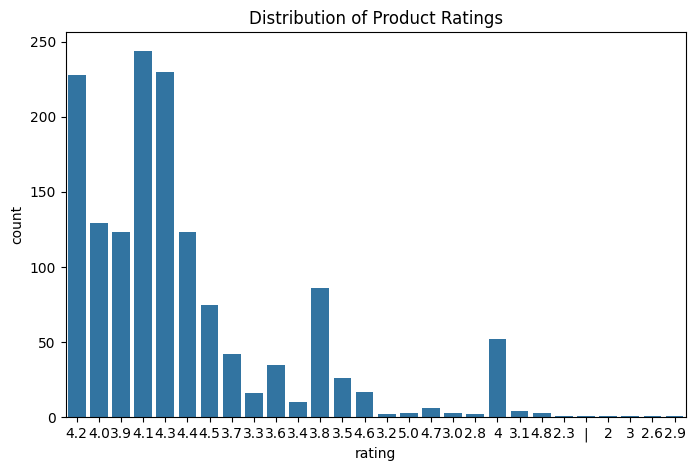

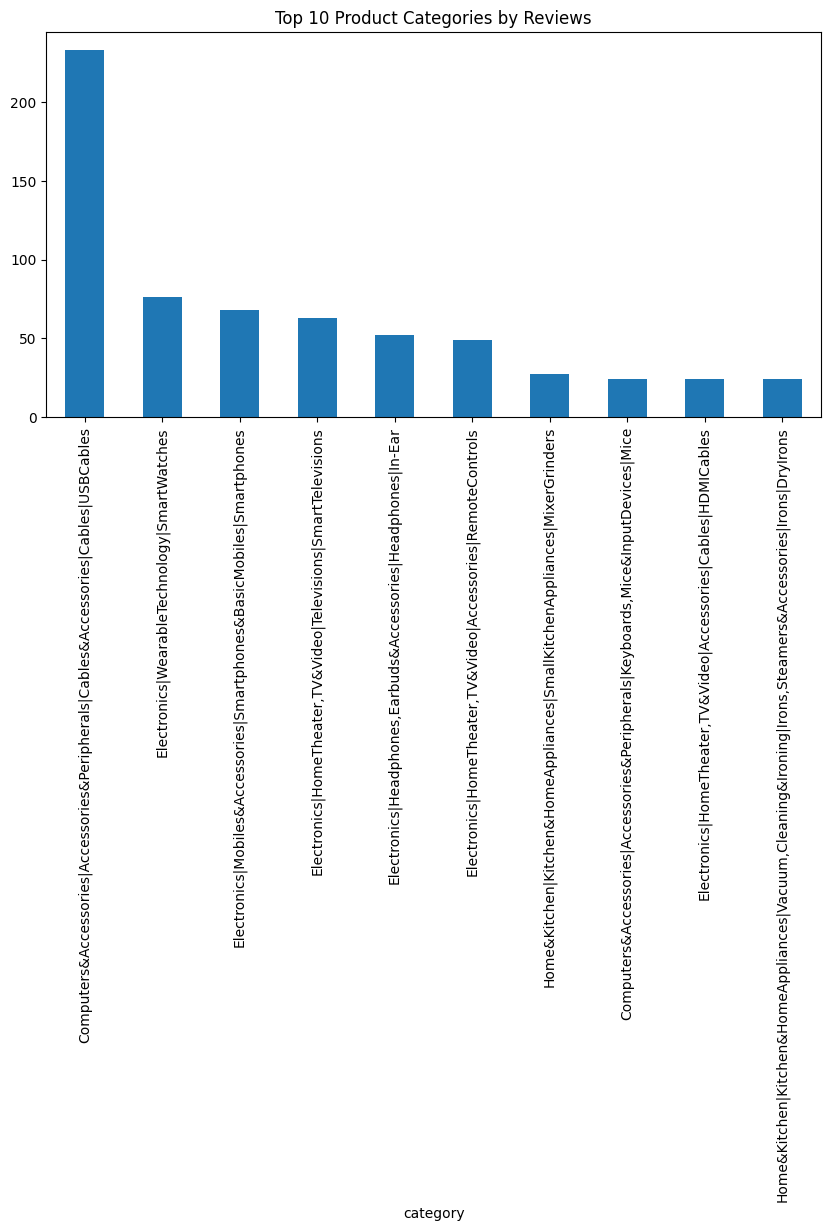

In [ ]:
# Distribution of ratings
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=df_clean)
plt.title('Distribution of Product Ratings')
plt.show()

# Top categories by review count
top_categories = df_clean['category'].value_counts().head(10)
top_categories.plot(kind='bar', figsize=(10, 5))
plt.title('Top 10 Product Categories by Reviews')
plt.show()

d. Sentiment Analysis

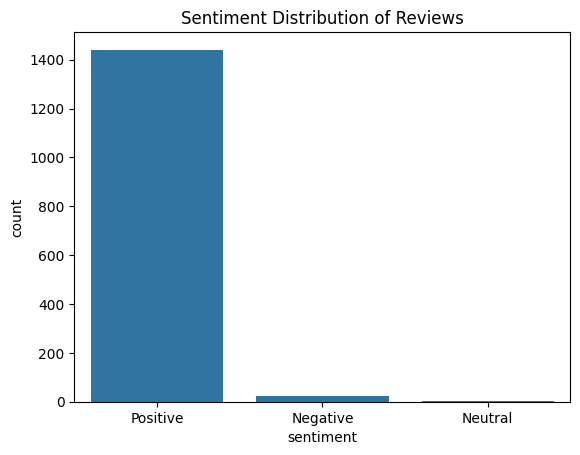

In [ ]:
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity  # -1 (negative) to 1 (positive)

df_clean['sentiment_score'] = df_clean['cleaned_review'].apply(get_sentiment)

# Classify sentiment
df_clean['sentiment'] = np.where(
    df_clean['sentiment_score'] > 0, 'Positive',
    np.where(df_clean['sentiment_score'] == 0, 'Neutral', 'Negative')
)

# Plot sentiment distribution
sns.countplot(x='sentiment', data=df_clean)
plt.title('Sentiment Distribution of Reviews')
plt.show()

In [ ]:
sia = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    return sia.polarity_scores(text)['compound']

df_clean['vader_score'] = df_clean['review_content'].apply(vader_sentiment)

# Compare TextBlob vs. VADER
print(df_clean[['review_content', 'sentiment_score', 'vader_score']].head())

                                      review_content  sentiment_score  \
0  Looks durable Charging is fine tooNo complains...         0.481944   
1  I ordered this cable to connect my phone to An...         0.274318   
2  Not quite durable and sturdy,https://m.media-a...         0.600000   
3  Good product,long wire,Charges good,Nice,I bou...         0.240370   
4  Bought this instead of original apple, does th...         0.262740   

   vader_score  
0       0.9033  
1       0.9853  
2       0.6808  
3       0.8316  
4       0.9809  


e. Word Cloud for Frequent Words

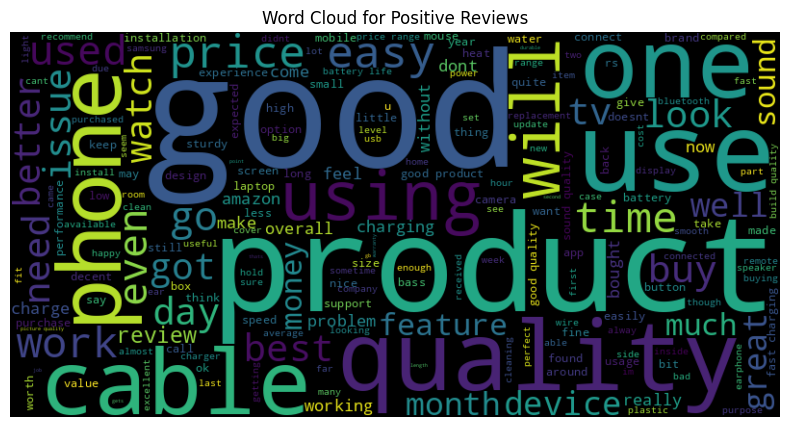

In [ ]:
# Generate word cloud for positive reviews
positive_reviews = ' '.join(df_clean[df_clean['sentiment'] == 'Positive']['cleaned_review'])
wordcloud = WordCloud(width=800, height=400).generate(positive_reviews)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()

f. Key Insights

In [ ]:
# Step 1: Clean the 'rating' column (convert to numeric, handle errors)
df_clean['rating'] = pd.to_numeric(df_clean['rating'], errors='coerce')  # Non-numeric → NaN

# Step 2: Drop rows with NaN in 'rating' or 'sentiment_score'
df_clean = df_clean.dropna(subset=['rating', 'sentiment_score'])

# Step 3: Now compute correlation
correlation = df_clean[['rating', 'sentiment_score']].corr()
print("Correlation between Rating and Sentiment Score:\n", correlation)

# Step 4: Top products by average sentiment
top_products = df_clean.groupby('product_name')['sentiment_score'].mean().sort_values(ascending=False).head(5)
print("\nTop 5 Products by Average Sentiment:\n", top_products)

Correlation between Rating and Sentiment Score:
                    rating  sentiment_score
rating           1.000000         0.178906
sentiment_score  0.178906         1.000000

Top 5 Products by Average Sentiment:
 product_name
Technotech High Speed HDMI Cable 5 Meter V1.4 - Supports Full HD 1080p (Color May Vary)                                                                                                                    1.000000
Khaitan ORFin Fan heater for Home and kitchen-K0 2215                                                                                                                                                      0.755000
CP PLUS 2MP Full HD Smart Wi-fi CCTV Security Camera | 360° with Pan Tilt | Two Way Talk | Cloud Monitor | Motion Detect | Night Vision | Supports SD Card (Up to 128 GB) | Alexa & Ok Google | CP-E21A    0.735000
Bajaj DHX-9 1000W Heavy Weight Dry Iron with Advance Soleplate and Anti-Bacterial German Coating Technology, Ivory                    

g. Export Processed Data

In [ ]:
df_clean.to_csv('processed_amazon_reviews.csv', index=False)

h. Deployment:

i) API (FastAPI/Flask)

In [ ]:
from fastapi import FastAPI
app = FastAPI()

@app.post("/analyze")
def analyze_review(review: str):
    sentiment = get_sentiment(review)
    return {"sentiment": "Positive" if sentiment > 0 else "Negative"}

ii) Dashboard:

In [ ]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 493.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.7 MB/s eta 0:00:00


In [ ]:
import streamlit as st
from textblob import TextBlob

# Sentiment analysis function
def get_sentiment(text):
    analysis = TextBlob(text)
    return "Positive" if analysis.sentiment.polarity > 0 else "Negative"

# Streamlit app
st.title('Amazon Review Analyzer')
user_input = st.text_input("Enter a review:")
if user_input:
    st.write("Sentiment:", get_sentiment(user_input))

2025-07-14 20:51:52.182 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-14 20:51:52.183 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-14 20:51:52.184 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-14 20:51:52.185 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-14 20:51:52.186 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-14 20:51:52.192 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-14 20:51:52.193 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-14 20:51:52.194 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar



---



5. **What KPIs should Amazon track to measure success?**

1. Customer-Centric KPIs

A. Purchase Behavior

Conversion Rate

% of visitors who complete a purchase.

Target: Increase YoY (e.g., 10-15%).

Average Order Value (AOV)

Revenue per order.

Target: Grow via upselling/cross-selling.

Repeat Purchase Rate

% of customers who buy again.

Target: >30% for Prime members.

B. Customer Satisfaction

Net Promoter Score (NPS)

Likelihood customers recommend Amazon (scale: -100 to 100).

Target: NPS >50 (e.g., 60 for Prime).

Customer Satisfaction (CSAT)

Post-purchase survey ratings (1-5 scale).

Target: >4.2/5.

Product Review Sentiment

NLP analysis of review positivity/negativity.

Target: 80%+ positive sentiment.

C. Retention & Loyalty

Prime Membership Growth

Subscriber count and retention rate.

Target: 10% YoY growth.

Churn Rate

% of customers who stop purchasing.

Target: <5% for Prime, <15% non-Prime.

2. Operational KPIs

A. Supply Chain & Logistics

On-Time Delivery Rate

% of orders delivered by promised date.

Target: >98% for Prime.

Inventory Turnover

How quickly stock is sold/replenished.

Target: 8-10x/year (varies by category).

Fulfillment Cost per Order

Labor, shipping, and storage costs.

Target: Reduce YoY via automation.

B. Platform Performance

Page Load Time

Speed of Amazon’s website/app.

Target: <2 seconds.

Search Accuracy

% of searches leading to conversions.

Target: >25% click-to-purchase rate.

3. Financial KPIs

Revenue Growth

Total sales (split by e-commerce, AWS, ads).

Target: 15-20% YoY.

Gross Profit Margin

Profit after cost of goods sold (COGS).

Target: ~40% (e-commerce), ~60% (AWS).

Advertising Revenue

Growth in sponsored product sales.

Target: 30% YoY increase.

4. AWS-Specific KPIs

Annual Recurring Revenue (ARR)

Predictable subscription revenue.

Target: 20%+ YoY growth.

Customer Downtime

AWS uptime (e.g., 99.99% SLA).

Target: <0.1% downtime/year.

5. Strategic KPIs

Market Share

% of total e-commerce/AWS market.

Target: Maintain #1 in e-commerce (~40% US share).

Carbon Footprint

Progress toward net-zero emissions.

Target: 50% reduction by 2030.



---





---

#################### Project 2 - Suchismita Sengupta ####################



---

